# REST EEG Connectivity Analysis

静息态脑电数据的连接性分析
- 计算PLI连接性矩阵 (5个频段)
- 计算小世界网络指标
- 生成可视化和统计结果

**分析需求:**
- 组水平描述性分析 + 与行为/临床数据相关分析
- 全部5个频段: delta, theta, alpha, beta, gamma
- 保留全矩阵(加权网络)
- 静态分析为主

## 变量参考表 (Variable Reference)

### 分组配置变量 (Group Configuration)
| 变量名 | 类型 | 说明 | 定义位置 |
|--------|------|------|----------|
| `GROUP_NAME` | `str` | 当前分析组 ('adhd'/'com'/'td'/'all') | cell-4 |
| `SUBJECT_GROUPS` | `Dict[str, List]` | 被试分组定义 {adhd/com/td: [IDs]} | cell-4 |

### 路径配置变量 (Path Configuration)
| 变量名 | 类型 | 说明 | 定义位置 |
|--------|------|------|----------|
| `DATA_ROOT` | `Path` | 项目根目录 | cell-4 |
| `EPOCH_DATA_PATH` | `Path` | 预处理epoch数据目录 (按组分子目录: adhd/, com/, td/) | cell-4 |
| `OUTPUT_PATH` | `Path` | 输出目录 (按组分开) | cell-4 |
| `RESULTS_PATH` | `Path` | 结果文件目录 | cell-4 |
| `FIGURES_PATH` | `Path` | 图片输出目录 | cell-4 |

### 分析参数变量 (Analysis Parameters)
| 变量名 | 类型 | 说明 | 定义位置 |
|--------|------|------|----------|
| `SUB_IDS` | `List[str]` | 被试ID列表 | cell-4 |
| `FREQ_BANDS` | `Dict[str, Tuple]` | 频段定义 {名称: (fmin, fmax)} | cell-4 |
| `TARGET_SFREQ` | `int` | 目标采样率 500Hz | cell-5 |
| `TARGET_SAMPLES` | `int` | 目标采样点数 5000 | cell-5 |
| `CONNECTIVITY_METHOD` | `str` | 连接性方法 'pli' | cell-4 |
| `NUM_RANDOM_GRAPHS` | `int` | 随机网络数量 50 | cell-4 |

### 数据变量 (Data)
| 变量名 | 类型 | Shape | 说明 | 定义位置 |
|--------|------|-------|------|----------|
| `epochs_dict` | `Dict[str, Epochs]` | {sub_id: Epochs} | 所有被试的epoch数据 | cell-7 |
| `connectivity_data` | `Dict[str, ndarray]` | {band: (n, 60, 60)} | 各频段连接性矩阵 | cell-14 |
| `metrics_df` | `DataFrame` | (n×5, 7) | 小世界指标(长格式,含group列) | cell-19 |
| `c_rand`, `l_rand` | `float` | scalar | 随机网络基线指标 | cell-18 |

### 输出变量 (Output)
| 变量名 | 类型 | 说明 | 保存路径 |
|--------|------|------|----------|
| `data_summary` | `DataFrame` | 数据验证摘要 | `{GROUP}/results/data_summary.csv` |
| `desc_stats` | `DataFrame` | 描述性统计 | `{GROUP}/results/descriptive_stats.csv` |
| `subject_summary` | `DataFrame` | 被试级汇总(宽格式) | `{GROUP}/results/subject_level_metrics.csv` |
| `connectivity_data` | `npz` | 连接性矩阵 | `{GROUP}/results/connectivity_results.npz` |

### 数据血缘概览 (Data Lineage Overview)
```
GROUP_NAME → get_subject_ids() → SUB_IDS
                                    ↓
EPOCH_DATA_PATH → get_epoch_path() → load_epochs() → epochs_dict
                                                        ↓
                                          compute_all_connectivity()
                                                        ↓
                                            connectivity_data ──→ 可视化
                                                        ↓
                                    compute_all_small_world_metrics()
                                                        ↓
                                                metrics_df (含group列) ──→ 可视化
                                                        ↓
                                       create_subject_level_summary()
                                                        ↓
                                                subject_summary
```

## 1. 导入库和配置参数

In [43]:
%matplotlib inline

import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings

import numpy as np
import pandas as pd
import mne
from mne_connectivity import spectral_connectivity_epochs
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from tqdm.notebook import tqdm  # notebook版本的进度条

# 忽略MNE的一些警告
warnings.filterwarnings('ignore', category=RuntimeWarning)

# 设置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print(f"MNE版本: {mne.__version__}")
print(f"NumPy版本: {np.__version__}")

MNE版本: 1.8.0
NumPy版本: 1.23.5


In [44]:
# =============================================================================
# 被试分组配置
# =============================================================================
# GROUP_NAME: str - 当前分析的被试组名称
# 可选: 'adhd', 'com' (共患), 'td' (典型发展), 'all' (所有被试)
GROUP_NAME: str = 'com'

# SUBJECT_GROUPS: Dict[str, List[str]] - 被试ID列表
SUBJECT_GROUPS: Dict[str, List[str]] = {
    'adhd': ['018', '029', '031', '037', '038', '045', '075', '091', '094', '117', '132', '134'],
    'com': ['001', '020', '021', '022', '024', '047', '049', '051', '072', '073', '076', '092', '113', '150'],
    'td': ['006', '068', '079', '093', '108', '109', '127', '133'],
}

# =============================================================================
# 数据路径配置
# =============================================================================
# DATA_ROOT: Path - 项目根目录
DATA_ROOT: Path = Path(r'd:\LYW\REST_COM')

# EPOCH_DATA_PATH: Path - 预处理后的epoch数据目录 (按组分子目录: adhd/, com/, td/)
EPOCH_DATA_PATH: Path = DATA_ROOT / 'preprocessing' / 'data' / '6epoch_clean'

# =============================================================================
# 根据GROUP_NAME生成被试列表
# =============================================================================
def get_subject_ids(group_name: str) -> List[str]:
    """根据组名返回被试ID列表"""
    if group_name == 'all':
        sub_ids = []
        for group, ids in SUBJECT_GROUPS.items():
            sub_ids.extend(ids)
        return sub_ids
    else:
        return list(SUBJECT_GROUPS.get(group_name, []))

def get_group_from_id(sub_id: str) -> str:
    """从被试ID查找所属组别"""
    for group, ids in SUBJECT_GROUPS.items():
        if sub_id in ids:
            return group
    return 'unknown'

def get_epoch_path(sub_id: str) -> Path:
    """根据被试ID获取epoch文件路径 (自动定位到对应组子目录)"""
    group = get_group_from_id(sub_id)
    return EPOCH_DATA_PATH / group / f'{sub_id}-epo.fif'

# SUB_IDS: List[str] - 当前分析的被试ID列表
SUB_IDS: List[str] = get_subject_ids(GROUP_NAME)

# =============================================================================
# 输出路径配置 - 按组分开
# =============================================================================
OUTPUT_PATH: Path = DATA_ROOT / 'analysis' / 'connectivity_analysis' / GROUP_NAME
RESULTS_PATH: Path = OUTPUT_PATH / 'results'
FIGURES_PATH: Path = OUTPUT_PATH / 'figures'

# 创建输出目录
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 分析参数配置
# =============================================================================
# SFREQ: int - 采样率 (Hz)
SFREQ: int = 500

# FREQ_BANDS: Dict[str, Tuple[float, float]] - 频段定义
FREQ_BANDS: Dict[str, Tuple[float, float]] = {
    'delta': (1, 4),    # Delta: 1-4 Hz
    'theta': (4, 8),    # Theta: 4-8 Hz
    'alpha': (8, 13),   # Alpha: 8-13 Hz
    'beta': (13, 30),   # Beta: 13-30 Hz
    'gamma': (30, 45)   # Gamma: 30-45 Hz
}

# CONNECTIVITY_METHOD: str - 连接性计算方法
CONNECTIVITY_METHOD: str = 'pli'

# N_JOBS: int - 并行作业数
N_JOBS: int = 4

# NUM_RANDOM_GRAPHS: int - 随机网络基线数量
NUM_RANDOM_GRAPHS: int = 50

# =============================================================================
# 配置摘要
# =============================================================================
print("=" * 60)
print("配置完成!")
print("=" * 60)
print(f"当前分析组: {GROUP_NAME}")
print(f"被试数量: {len(SUB_IDS)}")
print(f"被试列表: {SUB_IDS[:3]}..." if len(SUB_IDS) > 3 else f"被试列表: {SUB_IDS}")
print(f"数据路径: {EPOCH_DATA_PATH}")
print(f"输出路径: {OUTPUT_PATH}")
print(f"频段数量: {len(FREQ_BANDS)}")

配置完成!
当前分析组: com
被试数量: 14
被试列表: ['001', '020', '021']...
数据路径: d:\LYW\REST_COM\preprocessing\data\6epoch_clean
输出路径: d:\LYW\REST_COM\analysis\connectivity_analysis\com
频段数量: 5


In [45]:
# =============================================================================
# 数据对齐参数
# =============================================================================
# TARGET_SFREQ: int - 目标采样率 (Hz)
TARGET_SFREQ: int = 500

# TARGET_DURATION: float - 目标epoch时长 (秒)
TARGET_DURATION: float = 10.0

# TARGET_SAMPLES: int - 目标采样点数
TARGET_SAMPLES: int = int(TARGET_SFREQ * TARGET_DURATION)  # 5000

# =============================================================================
# 数据加载函数
# =============================================================================
def load_epochs(sub_id: str) -> Optional[mne.Epochs]:
    """
    加载单个被试的epoch数据并对齐
    
    Parameters
    ----------
    sub_id : str
        被试ID (如 '001', '006')
        
    Returns
    -------
    epochs : mne.Epochs or None
        对齐后的Epochs对象，加载失败返回None
    """
    fif_path = get_epoch_path(sub_id)
    
    if not fif_path.exists():
        print(f"  ⚠️ 文件不存在: {fif_path}")
        return None
    
    try:
        epochs = mne.read_epochs(fif_path, preload=True, verbose=False)
        
        # 1. 采样率对齐
        if epochs.info['sfreq'] != TARGET_SFREQ:
            print(f"  重采样 {sub_id}: {epochs.info['sfreq']} → {TARGET_SFREQ} Hz")
            epochs = epochs.resample(TARGET_SFREQ)
        
        # 2. Epoch长度对齐
        n_times = len(epochs.times)
        if n_times != TARGET_SAMPLES:
            tmax = (TARGET_SAMPLES - 1) / TARGET_SFREQ
            epochs = epochs.crop(tmin=0, tmax=tmax)
            print(f"  裁剪 {sub_id}: {n_times} → {TARGET_SAMPLES} 采样点")
        
        return epochs
        
    except Exception as e:
        print(f"  ⚠️ 加载失败 {sub_id}: {e}")
        return None


def load_all_subjects(
    sub_ids: List[str] = SUB_IDS
) -> Dict[str, mne.Epochs]:
    """
    加载所有被试的epoch数据
    
    Parameters
    ----------
    sub_ids : List[str]
        被试ID列表
        
    Returns
    -------
    epochs_dict : Dict[str, mne.Epochs]
        {被试ID: Epochs对象}
    """
    print("=" * 60)
    print(f"加载被试数据 (共 {len(sub_ids)} 人)")
    print(f"数据路径: {EPOCH_DATA_PATH}")
    print("=" * 60)
    
    epochs_dict = {}
    
    for sub_id in tqdm(sub_ids, desc="加载进度"):
        epochs = load_epochs(sub_id)
        if epochs is not None:
            epochs_dict[sub_id] = epochs
    
    print("\n" + "=" * 60)
    print(f"成功加载 {len(epochs_dict)}/{len(sub_ids)} 个被试")
    print(f"所有数据已对齐到: {TARGET_SFREQ} Hz, {TARGET_SAMPLES} 采样点")
    print("=" * 60)
    
    return epochs_dict


print("数据加载函数已定义:")
print("  - load_epochs(sub_id)")
print("  - load_all_subjects(sub_ids)")

数据加载函数已定义:
  - load_epochs(sub_id)
  - load_all_subjects(sub_ids)


## 2. 数据加载与验证

In [46]:
# epochs_dict: Dict[str, mne.Epochs]
# 结构: {被试ID: Epochs对象}
# 每个Epochs shape: (n_epochs, n_channels, n_times) ≈ (25, 60, 5000)
# 数据血缘: DATA_PATH → load_epochs() → epochs_dict
epochs_dict: Dict[str, mne.Epochs] = load_all_subjects()

加载被试数据 (共 14 人)
数据路径: d:\LYW\REST_COM\preprocessing\data\6epoch_clean


加载进度:   0%|          | 0/14 [00:00<?, ?it/s]

  裁剪 001: 5001 → 5000 采样点
  裁剪 020: 5001 → 5000 采样点
  裁剪 021: 5001 → 5000 采样点
  裁剪 022: 5001 → 5000 采样点
  裁剪 024: 5001 → 5000 采样点
  裁剪 047: 5001 → 5000 采样点
  裁剪 049: 5001 → 5000 采样点
  裁剪 051: 5001 → 5000 采样点
  裁剪 072: 5001 → 5000 采样点
  裁剪 073: 5001 → 5000 采样点
  裁剪 076: 5001 → 5000 采样点
  裁剪 092: 5001 → 5000 采样点
  裁剪 113: 5001 → 5000 采样点
  裁剪 150: 5001 → 5000 采样点

成功加载 14/14 个被试
所有数据已对齐到: 500 Hz, 5000 采样点


In [47]:
def validate_data(epochs_dict: Dict[str, mne.Epochs]) -> pd.DataFrame:
    """验证数据完整性并返回数据概要"""
    summary = []
    
    for sub_id, epochs in epochs_dict.items():
        info = {
            'subject_id': sub_id,
            'n_epochs': len(epochs),
            'n_channels': len(epochs.ch_names),
            'sfreq': epochs.info['sfreq'],
            'n_times': len(epochs.times),
            'tmin': epochs.tmin,
            'tmax': epochs.tmax,
            'duration': epochs.tmax - epochs.tmin
        }
        summary.append(info)
    
    df = pd.DataFrame(summary)
    return df

# 验证数据
data_summary = validate_data(epochs_dict)
print("\n数据验证摘要:")
display(data_summary)

# 检查数据一致性
print("\n数据一致性检查:")
print(f"  采样率统一: {data_summary['sfreq'].nunique() == 1} (目标: {TARGET_SFREQ} Hz)")
print(f"  采样点数统一: {data_summary['n_times'].nunique() == 1} (目标: {TARGET_SAMPLES} 点)")
print(f"  通道数统一: {data_summary['n_channels'].nunique() == 1}")

if data_summary['sfreq'].nunique() > 1:
    print(f"\n  ⚠️  警告: 检测到不同采样率: {data_summary['sfreq'].unique()}")
if data_summary['n_times'].nunique() > 1:
    print(f"\n  ⚠️  警告: 检测到不同采样点数: {data_summary['n_times'].unique()}")

# 保存数据摘要
data_summary.to_csv(RESULTS_PATH / 'data_summary.csv', index=False)
print(f"\n✓ 数据摘要已保存: {RESULTS_PATH / 'data_summary.csv'}")


数据验证摘要:


,subject_id,n_epochs,n_channels,sfreq,n_times,tmin,tmax,duration
0,001,24,60,500.0,5000,0.0,9.998,9.998
1,020,22,60,500.0,5000,0.0,9.998,9.998
2,021,24,60,500.0,5000,0.0,9.998,9.998
3,022,18,60,500.0,5000,0.0,9.998,9.998
4,024,22,60,500.0,5000,0.0,9.998,9.998
5,047,19,60,500.0,5000,0.0,9.998,9.998
6,049,20,60,500.0,5000,0.0,9.998,9.998
7,051,27,60,500.0,5000,0.0,9.998,9.998
8,072,27,60,500.0,5000,0.0,9.998,9.998
9,073,26,60,500.0,5000,0.0,9.998,9.998



数据一致性检查:
  采样率统一: True (目标: 500 Hz)
  采样点数统一: True (目标: 5000 点)
  通道数统一: True

✓ 数据摘要已保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\results\data_summary.csv


In [48]:
# 查看样例数据的通道信息
sample_sub = list(epochs_dict.keys())[0]
sample_epochs = epochs_dict[sample_sub]

print(f"样例被试: {sample_sub}")
print(f"通道数: {len(sample_epochs.ch_names)}")
print(f"通道名称: {sample_epochs.ch_names}")
print(f"\nEpoch信息:")
print(sample_epochs)

样例被试: 001
通道数: 60
通道名称: ['Fp1', 'F3', 'F7', 'F9', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'C4', 'Cz', 'FC2', 'FC6', 'F8', 'F4', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'FCz', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'F2', 'AF4', 'AF8']

Epoch信息:
<EpochsFIF | 24 events (all good), 0 – 9.998 s (baseline off), ~55.0 MiB, data loaded,
 '1': 24>


## 3. 连接性矩阵计算

In [49]:
def compute_connectivity_matrix(
    epochs: mne.Epochs,
    fmin: float,
    fmax: float,
    method: str = CONNECTIVITY_METHOD,
    n_jobs: int = N_JOBS
) -> np.ndarray:
    """
    计算单个被试单个频段的连接性矩阵
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoch数据
    fmin, fmax : float
        频率范围
    method : str
        连接性计算方法
    n_jobs : int
        并行作业数
        
    Returns
    -------
    adj_matrix : np.ndarray
        对称的邻接矩阵 (n_channels, n_channels)
    """
    con = spectral_connectivity_epochs(
        epochs,
        method=method,
        mode='multitaper',
        sfreq=epochs.info['sfreq'],
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        mt_adaptive=False,
        n_jobs=n_jobs,
        verbose=False
    )
    
    # 获取连接性矩阵
    mat = con.get_data(output='dense')[:, :, 0]
    
    # 对称化 (PLI本身应该是对称的,但确保一下)
    adj_matrix = mat + mat.T - np.diag(mat.diagonal())
    
    return adj_matrix

In [50]:
def compute_all_connectivity(
    epochs_dict: Dict[str, mne.Epochs],
    freq_bands: Dict[str, Tuple[float, float]] = FREQ_BANDS
) -> Dict[str, np.ndarray]:
    """
    计算所有被试所有频段的连接性矩阵
    
    Parameters
    ----------
    epochs_dict : Dict[str, mne.Epochs]
        {被试ID: Epochs对象}
    freq_bands : Dict[str, Tuple[float, float]]
        频段定义 {频段名: (fmin, fmax)}
        
    Returns
    -------
    connectivity_data : Dict[str, np.ndarray]
        {频段名: 连接性矩阵数组}
        每个数组 shape: (n_subjects, n_channels, n_channels)
    """
    print("\n" + "=" * 60)
    print("计算连接性矩阵...")
    print("=" * 60)
    
    sub_ids = list(epochs_dict.keys())
    n_subjects = len(sub_ids)
    n_channels = len(list(epochs_dict.values())[0].ch_names)
    
    connectivity_data = {}
    
    for band_name, (fmin, fmax) in freq_bands.items():
        print(f"\n频段: {band_name} ({fmin}-{fmax} Hz)")
        
        # 初始化该频段的矩阵数组
        band_matrices = np.zeros((n_subjects, n_channels, n_channels))
        
        for i, sub_id in enumerate(tqdm(sub_ids, desc=f"  {band_name}")):
            epochs = epochs_dict[sub_id]
            adj_matrix = compute_connectivity_matrix(epochs, fmin, fmax)
            band_matrices[i] = adj_matrix
        
        connectivity_data[band_name] = band_matrices
        print(f"  完成: shape = {band_matrices.shape}")
    
    print("\n" + "=" * 60)
    print("连接性计算完成!")
    print("=" * 60)
    
    return connectivity_data

测试被试: 001
测试频段: alpha (8-13 Hz)

连接性矩阵形状: (60, 60)
连接性值范围: [0.0000, 0.5997]
平均连接强度: 0.2831


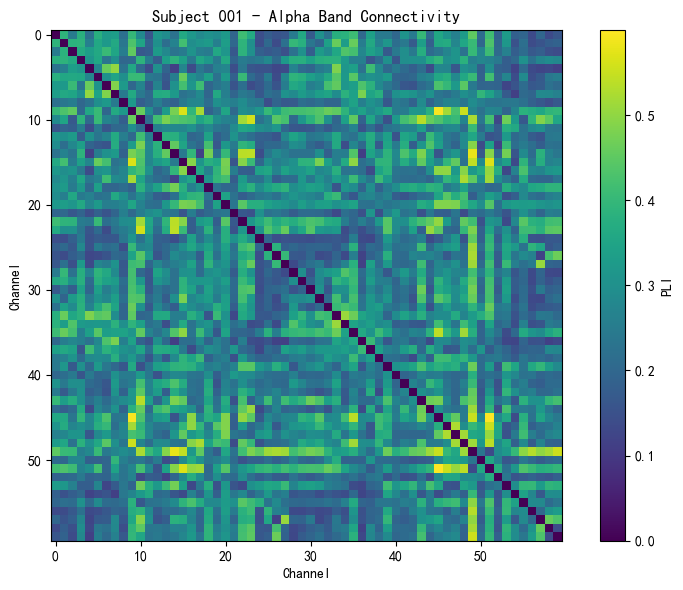

In [51]:
# 测试：计算单个被试单个频段的连接性
test_sub = list(epochs_dict.keys())[0]
test_epochs = epochs_dict[test_sub]

print(f"测试被试: {test_sub}")
print(f"测试频段: alpha (8-13 Hz)")

test_adj = compute_connectivity_matrix(test_epochs, fmin=8, fmax=13)

print(f"\n连接性矩阵形状: {test_adj.shape}")
print(f"连接性值范围: [{test_adj.min():.4f}, {test_adj.max():.4f}]")
print(f"平均连接强度: {np.mean(test_adj[np.triu_indices_from(test_adj, k=1)]):.4f}")

# 可视化测试结果
plt.figure(figsize=(8, 6))
plt.imshow(test_adj, cmap='viridis')
plt.colorbar(label='PLI')
plt.title(f'Subject {test_sub} - Alpha Band Connectivity')
plt.xlabel('Channel')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

In [52]:
# connectivity_data: Dict[str, np.ndarray]
# 结构: {频段名: 连接性矩阵}
# 每个矩阵 shape: (n_subjects, n_channels, n_channels) = (12, 60, 60)
# 值范围: [0, 1] (PLI值，0=无相位同步，1=完全同步)
# 数据血缘: epochs_dict → compute_connectivity_matrix() → connectivity_data
# 计算耗时: 约10-20分钟
connectivity_data: Dict[str, np.ndarray] = compute_all_connectivity(epochs_dict)


计算连接性矩阵...

频段: delta (1-4 Hz)


  delta:   0%|          | 0/14 [00:00<?, ?it/s]

  完成: shape = (14, 60, 60)

频段: theta (4-8 Hz)


  theta:   0%|          | 0/14 [00:00<?, ?it/s]

  完成: shape = (14, 60, 60)

频段: alpha (8-13 Hz)


...

  完成: shape = (14, 60, 60)

频段: beta (13-30 Hz)


  beta:   0%|          | 0/14 [00:00<?, ?it/s]

  完成: shape = (14, 60, 60)

频段: gamma (30-45 Hz)


  gamma:   0%|          | 0/14 [00:00<?, ?it/s]

  完成: shape = (14, 60, 60)

连接性计算完成!


In [53]:
# 保存连接性矩阵
sub_ids_list = list(epochs_dict.keys())
ch_names = list(epochs_dict.values())[0].ch_names

np.savez(
    RESULTS_PATH / 'connectivity_results.npz',
    **connectivity_data,
    subject_ids=sub_ids_list,
    channel_names=ch_names
)
print(f"✓ 连接性矩阵已保存: {RESULTS_PATH / 'connectivity_results.npz'}")

✓ 连接性矩阵已保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\results\connectivity_results.npz


## 4. 小世界网络指标计算

In [54]:
def precompute_random_baseline(
    n_nodes: int,
    n_edges: int,
    num_random: int = NUM_RANDOM_GRAPHS,
    seed: int = 42
) -> Tuple[float, float]:
    """
    预计算随机网络的基线指标
    
    Returns
    -------
    avg_clustering : float
        随机网络平均聚类系数
    avg_path_length : float  
        随机网络平均路径长度
    """
    rng = np.random.default_rng(seed)
    clustering_list = []
    path_length_list = []
    
    for _ in tqdm(range(num_random), desc="生成随机网络"):
        # 生成随机图
        G = nx.gnm_random_graph(n_nodes, n_edges, seed=int(rng.integers(1e9)))
        
        # 检查连通性
        if not nx.is_connected(G):
            continue
        
        # 分配随机权重
        for u, v in G.edges:
            G[u][v]['weight'] = rng.random()
        
        # 计算指标
        c = nx.average_clustering(G, weight='weight')
        l = nx.average_shortest_path_length(G, weight='weight')
        
        if c > 0 and l > 0:
            clustering_list.append(c)
            path_length_list.append(l)
    
    return np.mean(clustering_list), np.mean(path_length_list)

In [55]:
# n_nodes: int - 网络节点数（通道数）
# n_edges: int - 网络边数（全连接）
# c_rand: float - 随机网络平均聚类系数
# l_rand: float - 随机网络平均路径长度
# 数据血缘: connectivity_data[0][0].shape → n_nodes, n_edges → precompute_random_baseline() → c_rand, l_rand

sample_matrix: np.ndarray = list(connectivity_data.values())[0][0]
n_nodes: int = sample_matrix.shape[0]
n_edges: int = n_nodes * (n_nodes - 1) // 2

print(f"网络参数: {n_nodes} 节点, {n_edges} 边")
print(f"生成 {NUM_RANDOM_GRAPHS} 个随机网络基线...")

# 预计算随机基线 (用于小世界系数计算)
c_rand: float
l_rand: float
c_rand, l_rand = precompute_random_baseline(n_nodes, n_edges)
print(f"\n随机基线: C_rand={c_rand:.4f}, L_rand={l_rand:.4f}")

网络参数: 60 节点, 1770 边
生成 50 个随机网络基线...


生成随机网络:   0%|          | 0/50 [00:00<?, ?it/s]


随机基线: C_rand=0.4230, L_rand=0.0768


In [56]:
def compute_small_world_metrics(
    adj_matrix: np.ndarray,
    c_rand: float,
    l_rand: float
) -> Dict[str, float]:
    """
    计算单个网络的小世界指标
    """
    G = nx.from_numpy_array(adj_matrix)
    
    # 聚类系数
    clustering = nx.average_clustering(G, weight='weight')
    
    # 路径长度 (处理非连通图)
    if nx.is_connected(G):
        path_length = nx.average_shortest_path_length(G, weight='weight')
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc)
        path_length = nx.average_shortest_path_length(G_sub, weight='weight')
    
    # 小世界系数
    sigma = (clustering / c_rand) / (path_length / l_rand)
    
    # 平均连接强度
    avg_connectivity = np.mean(adj_matrix[np.triu_indices_from(adj_matrix, k=1)])
    
    return {
        'clustering': clustering,
        'path_length': path_length,
        'sigma': sigma,
        'avg_connectivity': avg_connectivity
    }


def compute_all_small_world_metrics(
    connectivity_data: Dict[str, np.ndarray],
    sub_ids: List[str],
    c_rand: float,
    l_rand: float
) -> pd.DataFrame:
    """
    计算所有被试所有频段的小世界指标
    """
    print("\n" + "="*60)
    print("计算小世界网络指标...")
    print("="*60)
    
    results = []
    
    for band_name, matrices in connectivity_data.items():
        print(f"\n处理频段: {band_name}")
        
        for i, sub_id in enumerate(tqdm(sub_ids, desc=f"  {band_name}")):
            adj = matrices[i]
            metrics = compute_small_world_metrics(adj, c_rand, l_rand)
            
            # 添加group列
            group = get_group_from_id(sub_id)
            
            results.append({
                'subject_id': sub_id,
                'group': group,
                'freq_band': band_name,
                **metrics
            })
    
    return pd.DataFrame(results)

# 计算小世界指标
sub_ids: List[str] = list(epochs_dict.keys())
metrics_df: pd.DataFrame = compute_all_small_world_metrics(connectivity_data, sub_ids, c_rand, l_rand)


计算小世界网络指标...

处理频段: delta


  delta:   0%|          | 0/14 [00:00<?, ?it/s]


处理频段: theta


  theta:   0%|          | 0/14 [00:00<?, ?it/s]


处理频段: alpha


  alpha:   0%|          | 0/14 [00:00<?, ?it/s]


处理频段: beta


  beta:   0%|          | 0/14 [00:00<?, ?it/s]


处理频段: gamma


  gamma:   0%|          | 0/14 [00:00<?, ?it/s]

In [57]:
# 查看结果
print("小世界指标结果:")
display(metrics_df.head(10))

# 保存结果
metrics_df.to_csv(RESULTS_PATH / 'small_world_metrics.csv', index=False)
print(f"\n✓ 小世界指标已保存: {RESULTS_PATH / 'small_world_metrics.csv'}")

小世界指标结果:


,subject_id,group,freq_band,clustering,path_length,sigma,avg_connectivity
0,001,com,delta,0.330051,0.166317,0.360289,0.168948
1,020,com,delta,0.388261,0.188351,0.374251,0.194269
2,021,com,delta,0.358493,0.182938,0.355781,0.195538
3,022,com,delta,0.474606,0.199915,0.431018,0.204621
4,024,com,delta,0.508742,0.182751,0.505412,0.185056
5,047,com,delta,0.487979,0.210875,0.420130,0.217538
6,049,com,delta,0.510706,0.187777,0.493784,0.191312
7,051,com,delta,0.480407,0.184417,0.472950,0.187376
8,072,com,delta,0.539396,0.269578,0.363271,0.283762
9,073,com,delta,0.411525,0.169301,0.441310,0.174408



✓ 小世界指标已保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\results\small_world_metrics.csv


In [58]:
def compute_descriptive_stats(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """计算描述性统计"""
    stats = metrics_df.groupby('freq_band').agg({
        'clustering': ['mean', 'std', 'min', 'max'],
        'path_length': ['mean', 'std', 'min', 'max'],
        'sigma': ['mean', 'std', 'min', 'max'],
        'avg_connectivity': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    return stats

# 计算描述性统计
desc_stats = compute_descriptive_stats(metrics_df)
print("描述性统计:")
display(desc_stats)

# 保存
desc_stats.to_csv(RESULTS_PATH / 'descriptive_stats.csv')
print(f"\n✓ 描述性统计已保存: {RESULTS_PATH / 'descriptive_stats.csv'}")

描述性统计:


clustering                         path_length                  \
                mean     std     min     max        mean     std     min   
freq_band                                                                  
alpha         0.4479  0.0435  0.3539  0.5246      0.2098  0.0318  0.1710   
beta          0.5336  0.1305  0.2568  0.7780      0.2007  0.0334  0.1627   
delta         0.4397  0.0810  0.2560  0.5394      0.1967  0.0281  0.1663   
gamma         0.4665  0.1775  0.2129  0.7350      0.1835  0.0225  0.1573   
theta         0.4750  0.0694  0.3385  0.5685      0.1972  0.0204  0.1622   

                    sigma                         avg_connectivity          \
              max    mean     std     min     max             mean     std   
freq_band                                                                    
alpha      0.2617  0.3942  0.0621  0.3075  0.5190           0.2143  0.0362   
beta       0.2923  0.4990  0.1534  0.2123  0.7153           0.2022  0.0369   
delta      0.2696  0.4068  0.0634  0.2653  0.5054           0.2019  0.0299   
gamma      0.2285  0.4651  0.1758  0.2039  0.7329           0.1843  0.0230   
theta      0.2401  0.4410  0.0764  0.3070  0.5876           0.2010  0.0212   

                           
              min     max  
freq_band                  
alpha      0.1718  0.2831  
beta       0.1627  0.3076  
delta      0.1689  0.2838  
gamma      0.1574  0.2285  
theta      0.1627  0.2424


✓ 描述性统计已保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\results\descriptive_stats.csv


## 6. 可视化

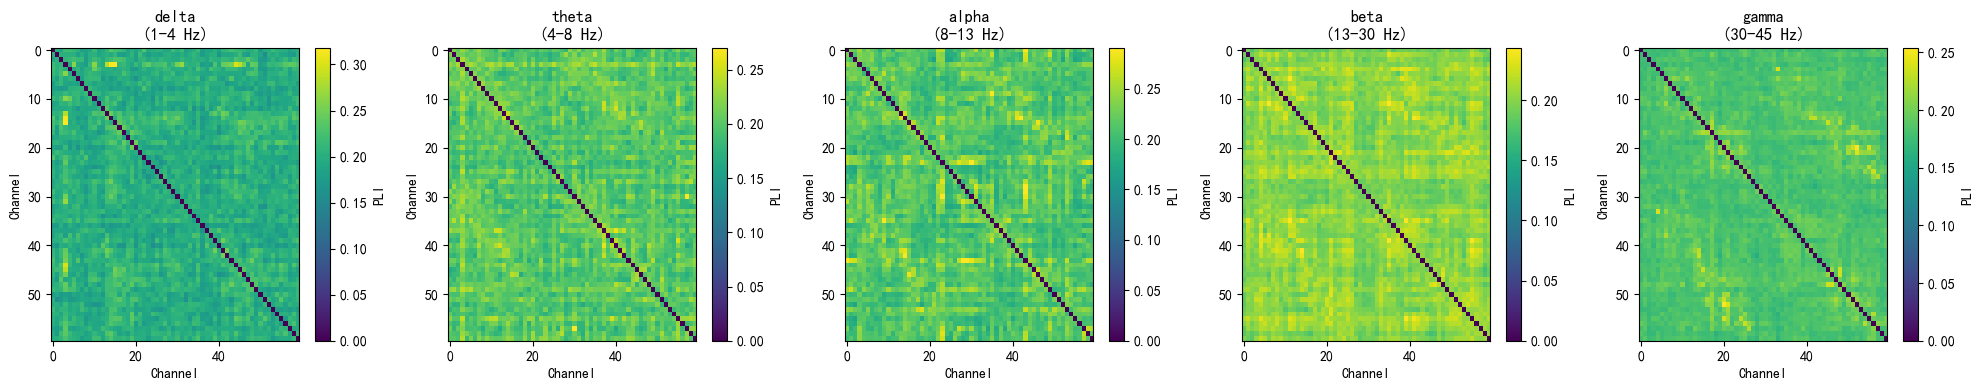

✓ 保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\figures\connectivity_heatmaps.png


In [59]:
# =============================================================================
# 6.1 各频段组平均连接性热图
# =============================================================================
# 变量血缘 (Data Lineage):
#   mean_matrix ← np.mean(matrices, axis=0)  # 跨被试平均
#     └── matrices ← connectivity_data[band_name]  # shape: (n, 60, 60)
#           └── connectivity_data ← compute_all_connectivity(epochs_dict)
#                 └── epochs_dict ← load_all_subjects()
# =============================================================================

n_bands: int = len(connectivity_data)
fig, axes = plt.subplots(1, n_bands, figsize=(4 * n_bands, 4))

if n_bands == 1:
    axes = [axes]

for ax, (band_name, matrices) in zip(axes, connectivity_data.items()):
    # mean_matrix: np.ndarray, shape (60, 60) - 组平均连接性矩阵
    mean_matrix: np.ndarray = np.mean(matrices, axis=0)
    
    # 绘制热图
    im = ax.imshow(mean_matrix, cmap='viridis', aspect='auto')
    ax.set_title(f'{band_name}\n({FREQ_BANDS[band_name][0]}-{FREQ_BANDS[band_name][1]} Hz)')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Channel')
    plt.colorbar(im, ax=ax, label='PLI')

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'connectivity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 保存: {FIGURES_PATH / 'connectivity_heatmaps.png'}")

# =============================================================================
# 6.1 各频段组平均连接性热图
# =============================================================================
# 变量血缘 (Data Lineage):
#   mean_matrix ← np.mean(matrices, axis=0)  # 跨被试平均
#     └── matrices ← connectivity_data[band_name]  # shape: (12, 60, 60)
#           └── connectivity_data ← compute_all_connectivity(epochs_dict) [cell-13]
#                 └── epochs_dict ← load_all_subjects() [cell-6]
#                       └── DATA_PATH [cell-3]
# =============================================================================

%matplotlib inline
n_bands: int = len(connectivity_data)
fig, axes = plt.subplots(1, n_bands, figsize=(4 * n_bands, 4))

if n_bands == 1:
    axes = [axes]

for ax, (band_name, matrices) in zip(axes, connectivity_data.items()):
    # mean_matrix: np.ndarray, shape (60, 60) - 组平均连接性矩阵
    mean_matrix: np.ndarray = np.mean(matrices, axis=0)
    
    # 绘制热图
    im = ax.imshow(mean_matrix, cmap='viridis', aspect='auto')
    ax.set_title(f'{band_name}\n({FREQ_BANDS[band_name][0]}-{FREQ_BANDS[band_name][1]} Hz)')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Channel')
    plt.colorbar(im, ax=ax, label='PLI')

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'connectivity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / 'connectivity_heatmaps.png'}")

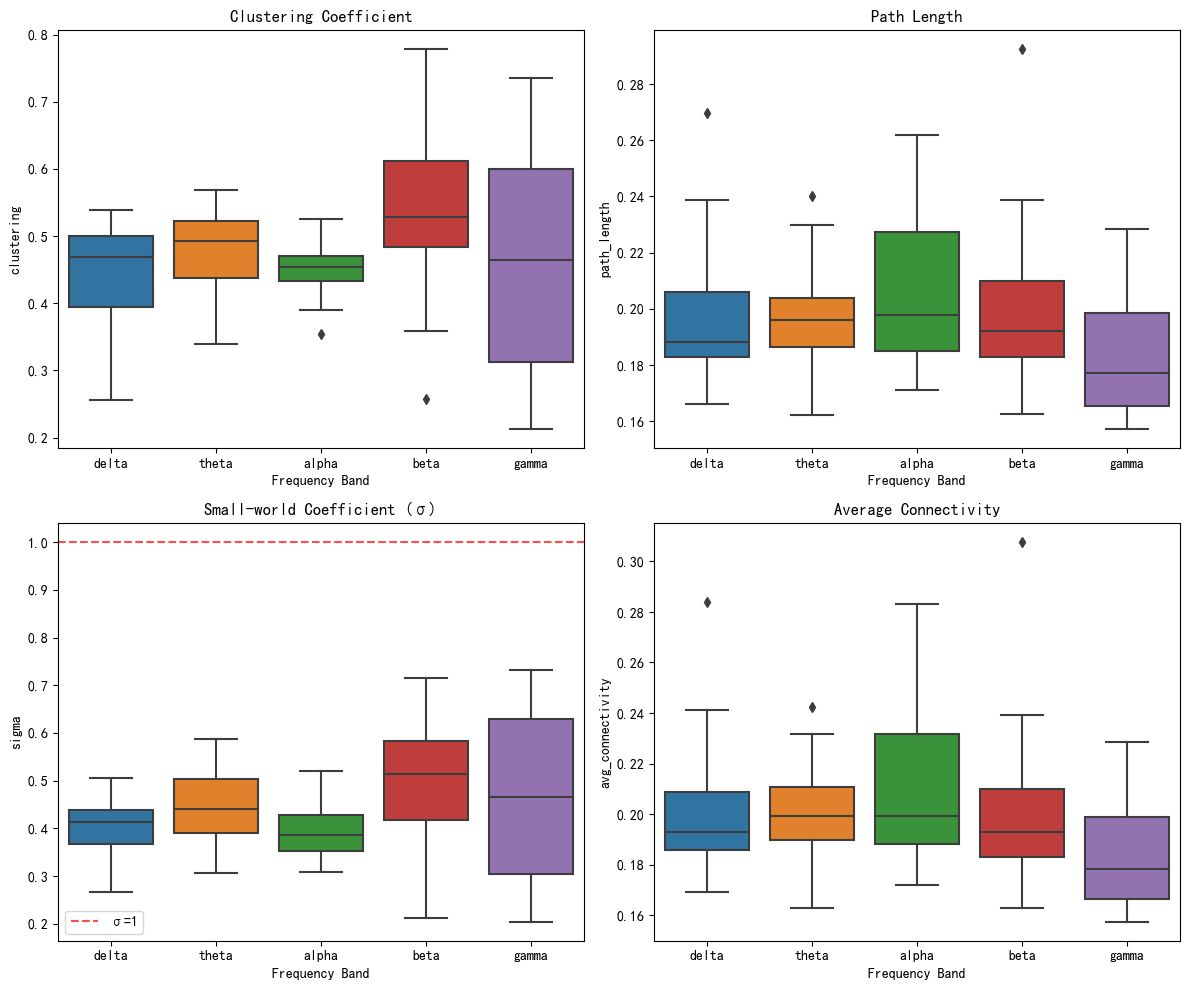

保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\figures\network_metrics_boxplot.png


In [60]:
# =============================================================================
# 6.2 网络指标箱线图
# =============================================================================
# 变量血缘 (Data Lineage):
#   metrics_df ← compute_all_small_world_metrics(connectivity_data, sub_ids, c_rand, l_rand) [cell-19]
#     ├── connectivity_data ← compute_all_connectivity(epochs_dict) [cell-13]
#     ├── sub_ids ← list(epochs_dict.keys()) [cell-19]
#     └── c_rand, l_rand ← precompute_random_baseline(n_nodes, n_edges) [cell-18]
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metric_names: List[str] = ['clustering', 'path_length', 'sigma', 'avg_connectivity']
titles: List[str] = ['Clustering Coefficient', 'Path Length', 'Small-world Coefficient (σ)', 'Average Connectivity']

for ax, metric, title in zip(axes.flat, metric_names, titles):
    sns.boxplot(data=metrics_df, x='freq_band', y=metric, ax=ax,
                order=['delta', 'theta', 'alpha', 'beta', 'gamma'])
    ax.set_title(title)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel(metric)
    
    # 添加参考线 (小世界系数=1)
    if metric == 'sigma':
        ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='σ=1')
        ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'network_metrics_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / 'network_metrics_boxplot.png'}")

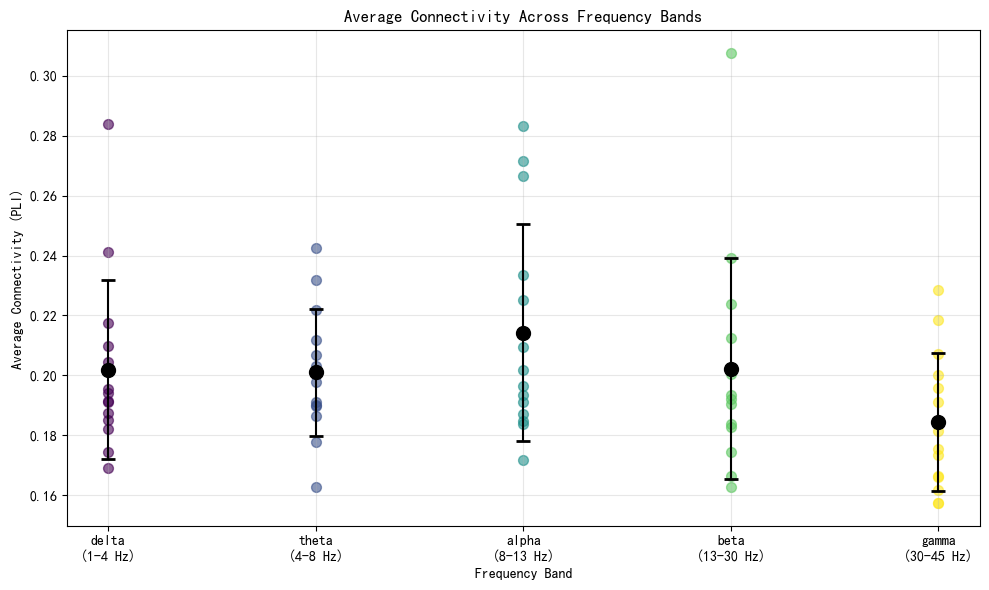

✓ 保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\figures\connectivity_by_band.png


In [61]:
# =============================================================================
# 6.4 各频段平均连接强度对比
# =============================================================================
# 变量血缘 (Data Lineage):
#   band_data ← metrics_df[metrics_df['freq_band'] == band]['avg_connectivity']
#     └── metrics_df ← compute_all_small_world_metrics(...)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

band_order = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = plt.cm.viridis(np.linspace(0, 1, len(band_order)))

for i, band in enumerate(band_order):
    band_data = metrics_df[metrics_df['freq_band'] == band]['avg_connectivity']
    ax.scatter([i] * len(band_data), band_data, color=colors[i], alpha=0.6, s=50, label=band)
    ax.errorbar(i, band_data.mean(), yerr=band_data.std(), color='black', capsize=5, capthick=2, fmt='o', markersize=10)

ax.set_xticks(range(len(band_order)))
ax.set_xticklabels([f"{b}\n({FREQ_BANDS[b][0]}-{FREQ_BANDS[b][1]} Hz)" for b in band_order])
ax.set_xlabel('Frequency Band')
ax.set_ylabel('Average Connectivity (PLI)')
ax.set_title('Average Connectivity Across Frequency Bands')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'connectivity_by_band.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 保存: {FIGURES_PATH / 'connectivity_by_band.png'}")

## 附录: 加载已保存的结果

如果需要重新加载之前保存的结果进行进一步分析:

C:\Users\Administrator\AppData\Local\Temp\ipykernel_595856\2915054853.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


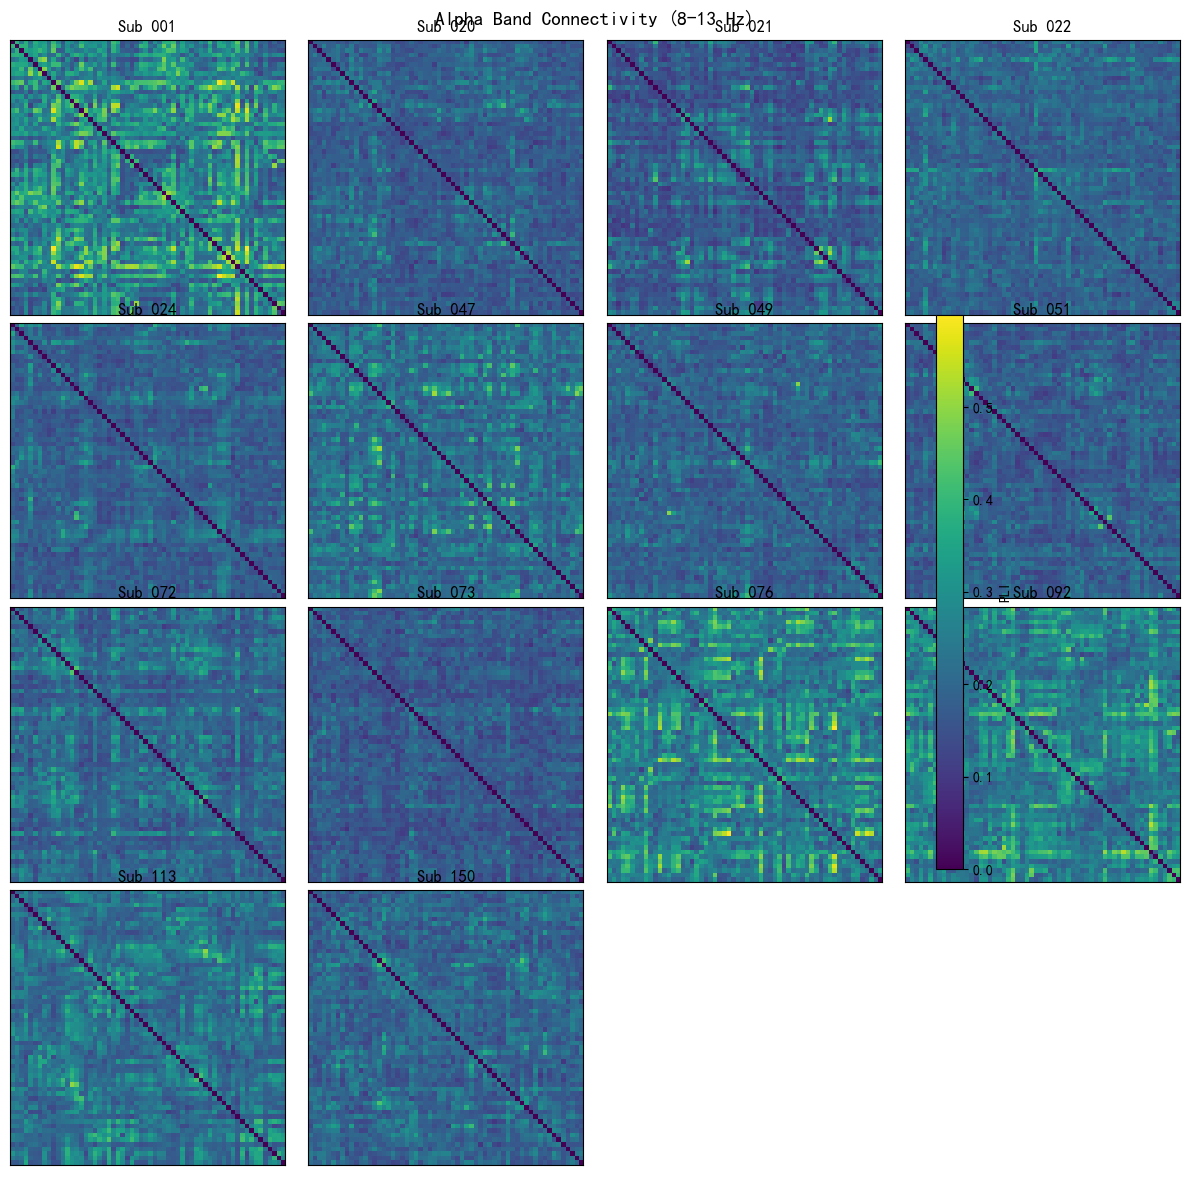

保存: d:\LYW\REST_COM\analysis\connectivity_analysis\com\figures\connectivity_individual_alpha.png


In [62]:
# =============================================================================
# 6.3 Alpha频段个体连接性热图
# =============================================================================
# 变量血缘 (Data Lineage):
#   matrices ← connectivity_data['alpha']  # shape: (12, 60, 60)
#     └── connectivity_data ← compute_all_connectivity(epochs_dict) [cell-13]
#   sub_ids ← list(epochs_dict.keys()) [cell-14]
#   vmin, vmax ← np.min/max(matrices) - 统一色标范围
# =============================================================================

band_name: str = 'alpha'
matrices: np.ndarray = connectivity_data[band_name]  # shape: (n_subjects, n_channels, n_channels)
n_subjects: int = len(sub_ids)

n_cols: int = 4
n_rows: int = (n_subjects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = axes.flatten()

# vmin, vmax: float - 统一色标范围，确保跨被试可比
vmin: float = np.min(matrices)
vmax: float = np.max(matrices)

for i, (sub_id, ax) in enumerate(zip(sub_ids, axes)):
    im = ax.imshow(matrices[i], cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Sub {sub_id}')
    ax.set_xticks([])
    ax.set_yticks([])

# 隐藏多余的子图
for j in range(len(sub_ids), len(axes)):
    axes[j].axis('off')

# 添加colorbar
fig.colorbar(im, ax=axes, shrink=0.6, label='PLI')
fig.suptitle(f'{band_name.capitalize()} Band Connectivity ({FREQ_BANDS[band_name][0]}-{FREQ_BANDS[band_name][1]} Hz)',
             fontsize=14)

plt.tight_layout()
fig.savefig(FIGURES_PATH / f'connectivity_individual_{band_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / f'connectivity_individual_{band_name}.png'}")

## 7. 分析完成总结

In [63]:
# 加载连接性矩阵
# loaded = np.load(RESULTS_PATH / 'connectivity_results.npz', allow_pickle=True)
# connectivity_data = {band: loaded[band] for band in FREQ_BANDS.keys()}
# sub_ids = loaded['subject_ids'].tolist()
# ch_names = loaded['channel_names'].tolist()

# 加载小世界指标
# metrics_df = pd.read_csv(RESULTS_PATH / 'small_world_metrics.csv')

# 加载被试级汇总
# subject_summary = pd.read_csv(RESULTS_PATH / 'subject_level_metrics.csv')